### **Logistic Regression: Predicting Heart Disease**

#### Objective:
Your task is to build a **Logistic Regression** model to predict whether a person has heart disease based on their medical and demographic information. This homework will help you understand how Logistic Regression is used for binary classification tasks.

---

#### Dataset:
Use the **Heart Disease dataset**, which contains information about patients' health parameters and whether they have heart disease.  

---

#### Dataset Overview:
The dataset contains the following key features:
- **Age**: Age of the person (in years).
- **Sex**: Gender (1 = male, 0 = female).
- **CP**: Chest pain type (categorical: 0, 1, 2, 3).
- **Trestbps**: Resting blood pressure (in mm Hg).
- **Chol**: Serum cholesterol (in mg/dL).
- **FBS**: Fasting blood sugar > 120 mg/dL (1 = true, 0 = false).
- **Restecg**: Resting electrocardiographic results (0, 1, 2).
- **Thalach**: Maximum heart rate achieved.
- **Exang**: Exercise-induced angina (1 = yes, 0 = no).
- **Oldpeak**: ST depression induced by exercise relative to rest.
- **Slope**: Slope of the peak exercise ST segment (categorical: 0, 1, 2).
- **CA**: Number of major vessels colored by fluoroscopy (0–3).
- **Thal**: Thalassemia (categorical: 0, 1, 2, 3).
- **Target**: **1** if the person has heart disease, **0** otherwise (binary target variable).

---

#### Steps to Complete:

1. **Data Loading and Exploration**
   - Load the dataset using `pandas`.
   - Explore the data:
     - Display the first few rows and column information.
     - Check for missing values and handle them appropriately.
     - Understand the distribution of each feature using histograms and box plots.
     - Visualize the correlation between features and the target variable.

2. **Data Preprocessing**
   - Convert categorical variables into numerical variables using one-hot encoding (e.g., `CP`, `Slope`, `Thal`).
   - Scale the features using StandardScaler or MinMaxScaler to improve the model's performance.
   - Split the dataset into training and test sets (e.g., 80% training, 20% testing).

3. **Model Building**
   - Train a Logistic Regression model using `LogisticRegression` from `sklearn.linear_model`.
   - Use different solvers (e.g., `liblinear`, `lbfgs`) and experiment with regularization techniques (`l1`, `l2` penalties).

4. **Model Evaluation**
   - Evaluate the model's performance on the test set using:
     - **Accuracy Score**
     - **Precision, Recall, and F1-Score**
     - **Confusion Matrix**
     - **ROC Curve and AUC Score**
   - Interpret the coefficients of the logistic regression model to understand the influence of each feature.

5. **Feature Importance**
   - Perform feature selection by analyzing p-values or using techniques like Recursive Feature Elimination (RFE).
   - Retrain the model with the most important features and compare performance.

6. **Prediction**
   - Predict whether a hypothetical patient with specific characteristics (provided in the problem) has heart disease.
   - Justify the prediction based on the model's coefficients.

---

#### Bonus Challenges (Optional):

1. **Hyperparameter Tuning**
   - Use `GridSearchCV` or `RandomizedSearchCV` to find the best combination of hyperparameters for the Logistic Regression model.

2. **Multiclass Classification**
   - Extend the task by using a dataset where the target variable has more than two classes (e.g., predicting chest pain types instead of heart disease).

3. **Comparison with Other Models**
   - Compare Logistic Regression's performance with other classification algorithms like:
     - Support Vector Machines (SVM)
     - Random Forest
     - k-Nearest Neighbors (kNN)

4. **Imbalanced Dataset Handling**
   - Introduce imbalance in the dataset (e.g., reduce the number of samples for the target = 1 class) and apply techniques like:
     - Oversampling using SMOTE.
     - Class weighting in the Logistic Regression model.

---

#### Deliverables:
- A Python script or Jupyter Notebook containing:
  - Code for loading, preprocessing, and visualizing the dataset.
  - Implementation of Logistic Regression with evaluation results.
  - Plots (e.g., ROC curve, confusion matrix) and performance metrics.
- A brief report addressing:
  - What factors were most predictive of heart disease?
  - How did hyperparameter tuning and feature selection impact the model?
  - Insights into the model's strengths and limitations.

---

#### Useful Hints:
- Use `seaborn` and `matplotlib` for data visualization.
- Use `sklearn.metrics` for model evaluation metrics.
- Start with a simple logistic regression model and progressively enhance it.

In [21]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

In [24]:
# Load dataset (CSV faylni shu yerga yuklab olasan)
df = pd.read_csv("data/heart_diceases.csv")

# Basic exploration
# print(df.head())
print(df.info())
# print(df['target'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [25]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [26]:
X = df.drop("target", axis=1)
y = df["target"]

# Identify categorical and numeric features
categorical = ["cp", "slope", "thal"]
numeric = [col for col in X.columns if col not in categorical]


In [27]:
# Preprocessor: OneHotEncoder for categorical + Scaler for numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ]
)

# Final pipeline: preprocessing + logistic regression
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("log_reg", LogisticRegression(max_iter=1000, solver="liblinear"))
])


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]


Accuracy: 0.8585365853658536
Precision: 0.8220338983050848
Recall: 0.9238095238095239
F1: 0.8699551569506726


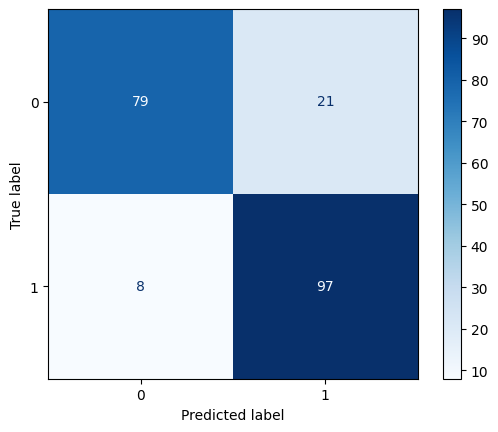

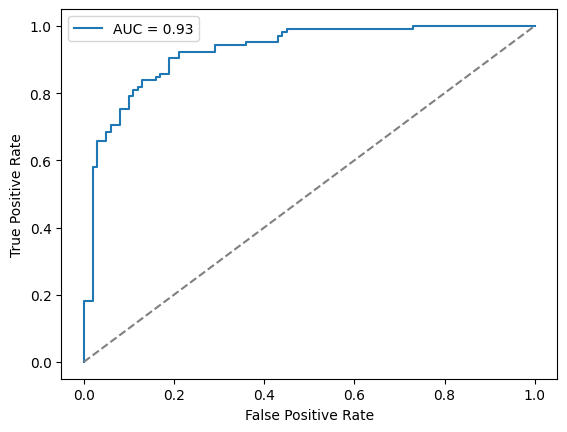

In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [30]:
param_grid = {
    "log_reg__C": [0.01, 0.1, 1, 10],
    "log_reg__penalty": ["l1", "l2"],
    "log_reg__solver": ["liblinear"]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Re-evaluate best model
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Tuned model F1:", f1_score(y_test, y_pred_best))


Best params: {'log_reg__C': 1, 'log_reg__penalty': 'l1', 'log_reg__solver': 'liblinear'}
Best CV score: 0.8618981575866865
Tuned model F1: 0.8699551569506726


In [31]:
# Extract feature names after preprocessing
ohe = grid.best_estimator_.named_steps["preprocess"].named_transformers_["cat"]
ohe_features = ohe.get_feature_names_out(categorical)
all_features = numeric + list(ohe_features)

coefs = grid.best_estimator_.named_steps["log_reg"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": all_features,
    "coef": coefs
}).sort_values(by="coef", key=abs, ascending=False)

print(feature_importance.head(10))


    feature      coef
11     cp_2  1.922407
12     cp_3  1.633215
17   thal_3 -1.125303
9        ca -0.787178
10     cp_1  0.779492
13  slope_1 -0.752762
1       sex -0.632391
8   oldpeak -0.559019
7     exang -0.446910
6   thalach  0.288289


In [32]:
patient = pd.DataFrame([{
    "age": 55,
    "sex": 1,
    "trestbps": 140,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 160,
    "exang": 0,
    "oldpeak": 1.5,
    "ca": 0,
    "cp": 2,
    "slope": 2,
    "thal": 2
}])

pred = best_model.predict(patient)[0]
proba = best_model.predict_proba(patient)[0][1]

print(f"Prediction: {pred} (Probability of heart disease = {proba:.2f})")


Prediction: 1 (Probability of heart disease = 0.92)
